# 04 - Image, Video, and Text Augmentation

This notebook groups three modalities that are commonly shown in separate demos but conceptually belong together:

- image augmentation
- video augmentation
- text augmentation

Each section includes a compact baseline and an augmented-data A/B test.


In [1]:
# Colab setup
%pip -q install -U tensorflow keras-cv nlpaug scikit-learn pandas matplotlib pillow opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 28.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not current

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_cv

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import nlpaug.augmenter.word as naw

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


## Part A - Image augmentation and classification


In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.squeeze()
y_test = y_test.squeeze()

x_train = x_train[:12000].astype("float32")
y_train = y_train[:12000]
x_test = x_test[:2000].astype("float32")
y_test = y_test[:2000]

val_size = 2000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr, y_tr = x_train[:-val_size], y_train[:-val_size]

augmenter = keras.Sequential(
    [
        keras_cv.layers.RandAugment(value_range=(0, 255), augmentations_per_image=2, magnitude=0.5),
        keras_cv.layers.RandomCutout(height_factor=0.15, width_factor=0.15),
    ]
)

AUTO = tf.data.AUTOTUNE

def ds_plain(images, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(4000)
    ds = ds.batch(128)
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

def ds_aug(images, labels):
    ds = tf.data.Dataset.from_tensor_slices((images, labels)).shuffle(4000).batch(128)
    ds = ds.map(lambda x, y: (tf.cast(augmenter(x, training=True), tf.float32) / 255.0, y), num_parallel_calls=AUTO)
    return ds.prefetch(AUTO)

train_plain = ds_plain(x_tr, y_tr, training=True)
train_aug = ds_aug(x_tr, y_tr)
val_ds = ds_plain(x_val, y_val)
test_ds = ds_plain(x_test, y_test)


In [5]:
def build_small_cnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(32, 32, 3)),
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(96, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.3),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

callbacks = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)]

image_baseline = build_small_cnn()
hist_image_base = image_baseline.fit(train_plain, validation_data=val_ds, epochs=8, callbacks=callbacks, verbose=1)
base_image_test = image_baseline.evaluate(test_ds, verbose=0)

image_aug = build_small_cnn()
hist_image_aug = image_aug.fit(train_aug, validation_data=val_ds, epochs=8, callbacks=callbacks, verbose=1)
aug_image_test = image_aug.evaluate(test_ds, verbose=0)

pd.DataFrame([
    {"experiment": "image_baseline", "test_acc": base_image_test[1]},
    {"experiment": "image_augmented", "test_acc": aug_image_test[1]},
])


Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.1787 - loss: 2.1751 - val_accuracy: 0.2490 - val_loss: 1.9926
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 0.2649 - loss: 1.9315 - val_accuracy: 0.3225 - val_loss: 1.8468
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.2905 - loss: 1.8349 - val_accuracy: 0.3115 - val_loss: 1.8111
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.3131 - loss: 1.7843 - val_accuracy: 0.3415 - val_loss: 1.7645
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.3299 - loss: 1.7468 - val_accuracy: 0.3640 - val_loss: 1.6905
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 162ms/step - accuracy: 0.3525 - loss: 1.7014 - val_accuracy: 0.3805 - val_loss: 1.6608
Epoch 7/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.3655 - loss: 1.6847 - val_accuracy: 0.3710 - val_loss: 1.6706
Epoch 8/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 161ms/step - accuracy: 0.3762 - loss: 1.6621 - val_accuracy: 0.

,experiment,test_acc
0,image_baseline,0.3900
1,image_augmented,0.2215


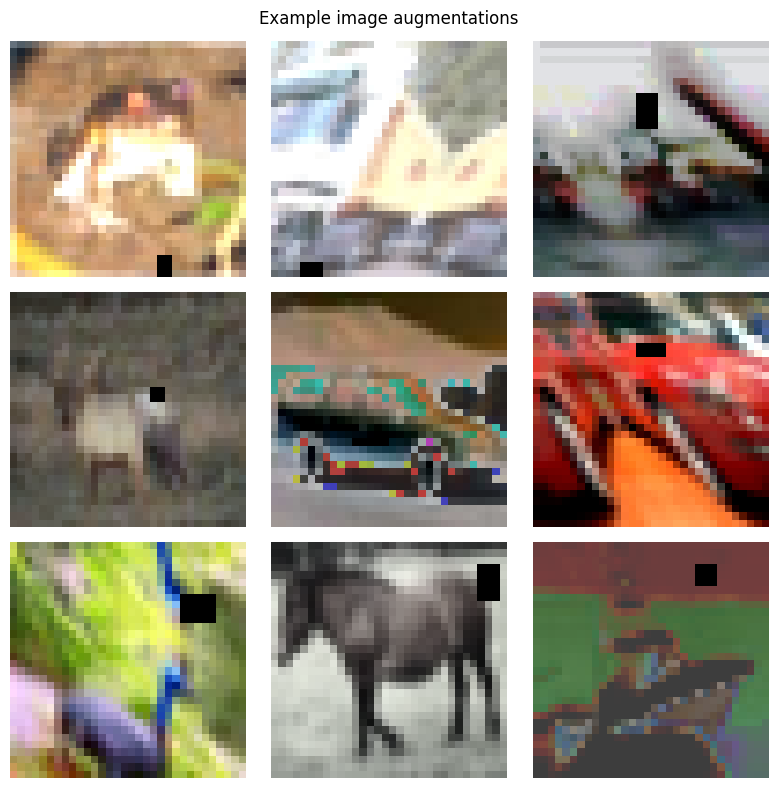

In [6]:
sample_images = x_tr[:9]
augmented_images = augmenter(sample_images, training=True).numpy().astype("uint8")

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img in zip(axes.ravel(), augmented_images):
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Example image augmentations")
plt.tight_layout()
plt.show()


## Part B - Synthetic video augmentation and classification

Real video datasets are heavy. For a Colab-friendly demonstration, we generate tiny synthetic clips where a bright square moves either:

- left-to-right
- top-to-bottom

That gives us a simple video classification problem with controllable augmentations.


In [7]:
def generate_motion_clip(direction="horizontal", frames=12, size=24, square=6):
    clip = np.zeros((frames, size, size, 1), dtype=np.float32)
    if direction == "horizontal":
        y = size // 2 - square // 2
        xs = np.linspace(0, size - square, frames).astype(int)
        for t, x in enumerate(xs):
            clip[t, y:y+square, x:x+square, 0] = 1.0
    else:
        x = size // 2 - square // 2
        ys = np.linspace(0, size - square, frames).astype(int)
        for t, y in enumerate(ys):
            clip[t, y:y+square, x:x+square, 0] = 1.0
    return clip

def augment_video_clip(clip):
    out = clip.copy()
    # gaussian noise
    out = out + np.random.normal(0, 0.05, size=out.shape).astype(np.float32)
    # mild brightness jitter
    out = out * np.random.uniform(0.8, 1.2)
    out = np.clip(out, 0.0, 1.0)
    # random crop and resize back
    pad = 2
    padded = np.pad(out, ((0,0), (pad,pad), (pad,pad), (0,0)))
    top = np.random.randint(0, pad * 2 + 1)
    left = np.random.randint(0, pad * 2 + 1)
    cropped = padded[:, top:top+clip.shape[1], left:left+clip.shape[2], :]
    return cropped

def build_video_dataset(n=300, augmented=False):
    clips = []
    labels = []
    for _ in range(n):
        clip_h = generate_motion_clip("horizontal")
        clip_v = generate_motion_clip("vertical")
        if augmented:
            clip_h = augment_video_clip(clip_h)
            clip_v = augment_video_clip(clip_v)
        clips.append(clip_h)
        labels.append(0)
        clips.append(clip_v)
        labels.append(1)
    X = np.stack(clips).astype("float32")
    y = np.array(labels)
    return X, y

X_video, y_video = build_video_dataset(n=250, augmented=False)
X_video_aug, y_video_aug = build_video_dataset(n=250, augmented=True)

Xv_train, Xv_val, yv_train, yv_val = train_test_split(X_video, y_video, test_size=0.2, random_state=SEED, stratify=y_video)
Xa_train, Xa_val, ya_train, ya_val = train_test_split(X_video_aug, y_video_aug, test_size=0.2, random_state=SEED, stratify=y_video_aug)

print(Xv_train.shape, Xv_val.shape)


(400, 12, 24, 24, 1) (100, 12, 24, 24, 1)


In [8]:
def build_video_model():
    inputs = keras.Input(shape=(12, 24, 24, 1))
    x = layers.Conv3D(16, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPool3D((1, 2, 2))(x)
    x = layers.Conv3D(32, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(2, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

video_base = build_video_model()
video_aug = build_video_model()

cb = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)]

hist_video_base = video_base.fit(
    Xv_train, yv_train, validation_data=(Xv_val, yv_val), epochs=8, batch_size=32, verbose=1, callbacks=cb
)

hist_video_aug = video_aug.fit(
    Xa_train, ya_train, validation_data=(Xa_val, ya_val), epochs=8, batch_size=32, verbose=1, callbacks=cb
)

video_df = pd.DataFrame([
    {"experiment": "video_baseline", "val_acc": max(hist_video_base.history["val_accuracy"])},
    {"experiment": "video_augmented", "val_acc": max(hist_video_aug.history["val_accuracy"])},
])
video_df


Epoch 1/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 348ms/step - accuracy: 0.4950 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6827
Epoch 2/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 351ms/step - accuracy: 0.8100 - loss: 0.6739 - val_accuracy: 1.0000 - val_loss: 0.6546
Epoch 3/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.9725 - loss: 0.6283 - val_accuracy: 1.0000 - val_loss: 0.5811
Epoch 4/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step - accuracy: 0.9950 - loss: 0.5357 - val_accuracy: 1.0000 - val_loss: 0.4607
Epoch 1/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 341ms/step - accuracy: 0.4775 - loss: 0.6906 - val_accuracy: 1.0000 - val_loss: 0.6785
Epoch 2/8
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step - accuracy: 0.8850 - loss: 0.6634 - val_accuracy: 1.0000 - val_loss: 0.6423


,experiment,val_acc
0,video_baseline,1.0
1,video_augmented,1.0


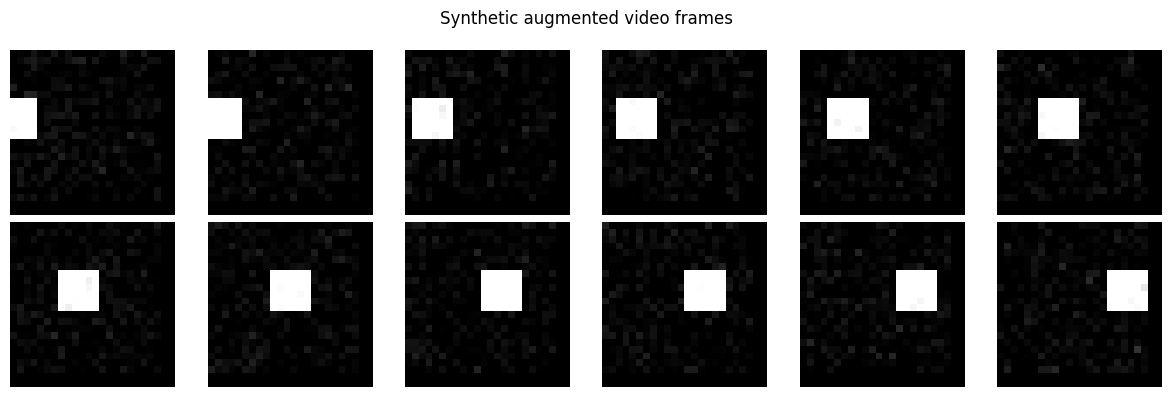

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
example_clip = augment_video_clip(generate_motion_clip("horizontal"))
for i in range(6):
    axes[0, i].imshow(example_clip[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(example_clip[i + 6, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
plt.suptitle("Synthetic augmented video frames")
plt.tight_layout()
plt.show()


## Part C - Text augmentation with `nlpaug`

We create a tiny sentiment dataset and expand the training set with synonym-based augmentation.

For a class demo, this is much lighter than running a large transformer and still clearly shows the workflow.


In [10]:
texts = [
    "the movie was excellent and emotionally rich",
    "what a wonderful and engaging story",
    "the acting was strong and the pacing was great",
    "i loved the visuals and the soundtrack",
    "this was a thoughtful and satisfying film",
    "the movie was boring and painfully slow",
    "the plot was weak and predictable",
    "i disliked the acting and the dialogue",
    "the film felt messy and confusing",
    "this was a disappointing and forgettable movie",
] * 30

labels = [1,1,1,1,1,0,0,0,0,0] * 30

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    texts, labels, test_size=0.25, random_state=SEED, stratify=labels
)

aug = naw.SynonymAug(aug_src="wordnet")

augmented_texts = []
augmented_labels = []
for text, label in zip(X_train_text[:120], y_train_text[:120]):
    try:
        augmented_texts.append(aug.augment(text))
        augmented_labels.append(label)
    except Exception:
        pass

train_texts_aug = X_train_text + augmented_texts
train_labels_aug = y_train_text + augmented_labels

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
Xtr_base = vectorizer.fit_transform(X_train_text)
Xte_base = vectorizer.transform(X_test_text)

clf_base = LogisticRegression(max_iter=300)
clf_base.fit(Xtr_base, y_train_text)
pred_base = clf_base.predict(Xte_base)
base_text_acc = accuracy_score(y_test_text, pred_base)

vectorizer_aug = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
Xtr_aug = vectorizer_aug.fit_transform(train_texts_aug)
Xte_aug = vectorizer_aug.transform(X_test_text)

clf_aug = LogisticRegression(max_iter=300)
clf_aug.fit(Xtr_aug, train_labels_aug)
pred_aug = clf_aug.predict(Xte_aug)
aug_text_acc = accuracy_score(y_test_text, pred_aug)

pd.DataFrame([
    {"experiment": "text_baseline", "test_acc": base_text_acc},
    {"experiment": "text_augmented", "test_acc": aug_text_acc},
])


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is al

,experiment,test_acc
0,text_baseline,1.0
1,text_augmented,1.0


In [11]:
for i in range(5):
    print("ORIGINAL :", X_train_text[i])
    try:
        print("AUGMENTED:", aug.augment(X_train_text[i]))
    except Exception:
        print("AUGMENTED: <augmentation skipped>")
    print("-" * 80)


ORIGINAL : the acting was strong and the pacing was great
AUGMENTED: <augmentation skipped>
--------------------------------------------------------------------------------
ORIGINAL : the film felt messy and confusing
AUGMENTED: <augmentation skipped>
--------------------------------------------------------------------------------
ORIGINAL : this was a disappointing and forgettable movie
AUGMENTED: <augmentation skipped>
--------------------------------------------------------------------------------
ORIGINAL : the movie was boring and painfully slow
AUGMENTED: <augmentation skipped>
--------------------------------------------------------------------------------
ORIGINAL : i disliked the acting and the dialogue
AUGMENTED: <augmentation skipped>
--------------------------------------------------------------------------------


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## Summary

This notebook shows the same idea across three modalities:

- augmentation expands the training distribution
- a baseline is important, otherwise the fancy stuff has nothing to beat
- small synthetic demos are perfectly acceptable for explaining the mechanics in a course repo

For the video, it is useful to emphasize that image, video, and text augmentation all serve the same meta-goal: make the model less fragile.
